# Multi-omics integration: tracing gene regulation in single cells

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nchernia/festival-multiomics-workshop/blob/main/workshop_multiomics_integration.ipynb)

A 10x Multiome PBMC dataset (RNA + ATAC measured in the same cells) — used to ask a single question end-to-end: **which transcription factors regulate which genes, in which cell types?**

The workshop runs in Colab — **Runtime → Run all**. ~5–10 minutes to execute, ~45 minutes to walk through.

A companion notebook `rna_annotation.ipynb` covers how the RNA cell-type labels were derived (consumed here as a given).


In [1]:
%%capture
!pip install -q muon scanpy alphagenome leidenalg igv-notebook

In [2]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import scanpy as sc, muon as mu
import scipy.sparse as sp
from scipy import stats

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor='white')

In [3]:
# Load the workshop .h5mu (RNA + ATAC for the same cells, plus precomputed embeddings,
# annotations, gene TSS table, and an AlphaGenome cache).
import os, urllib.request, pathlib
DATA_URL = os.environ.get(
    "DATA_URL",
    "https://storage.googleapis.com/broad-p16-calico/festival-2026/pbmc_10k_multiome_workshop.h5mu",
)
local = pathlib.Path("pbmc_10k_multiome_workshop.h5mu")
if not local.exists():
    print(f"Downloading {DATA_URL} -> {local} ...")
    urllib.request.urlretrieve(DATA_URL, local)
mdata = mu.read_h5mu(local)
rna  = mdata.mod['rna']
atac = mdata.mod['atac']
print(mdata)

MuData object with n_obs × n_vars = 10138 × 198300
  var:	'highly_variable'
  uns:	'alphagenome_cache', 'gene_tss'
  2 modalities
    rna:	10138 x 18842
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'cell_type'
      var:	'gene_ids', 'feature_types', 'genome', 'interval', 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_id', 'gene_type', 'tag', 'hgnc_id', 'havana_gene'
      uns:	'hvg', 'leiden', 'log1p', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    atac:	10138 x 179458
      obs:	'cell_type', 'tsse', 'n_f

## Part 1 — The puzzle of gene regulation

Every cell in your body carries the same DNA. A B-cell behaves nothing like a T-cell, and a monocyte nothing like either — yet they share a genome. The difference is *regulation*: which stretches of DNA are open, which transcription factors are bound, which genes get transcribed.

Studying regulation needs two measurements together:

- **Gene expression** — *which genes are on* (RNA-seq)
- **Chromatin accessibility** — *which DNA is open and reachable by regulators* (ATAC-seq)

And ideally **in the same cell**, so we can ask whether the gene's expression actually tracks the chromatin's openness across cell types. That's what 10x Multiome does — and that's the data this workshop uses.

<div align="center">
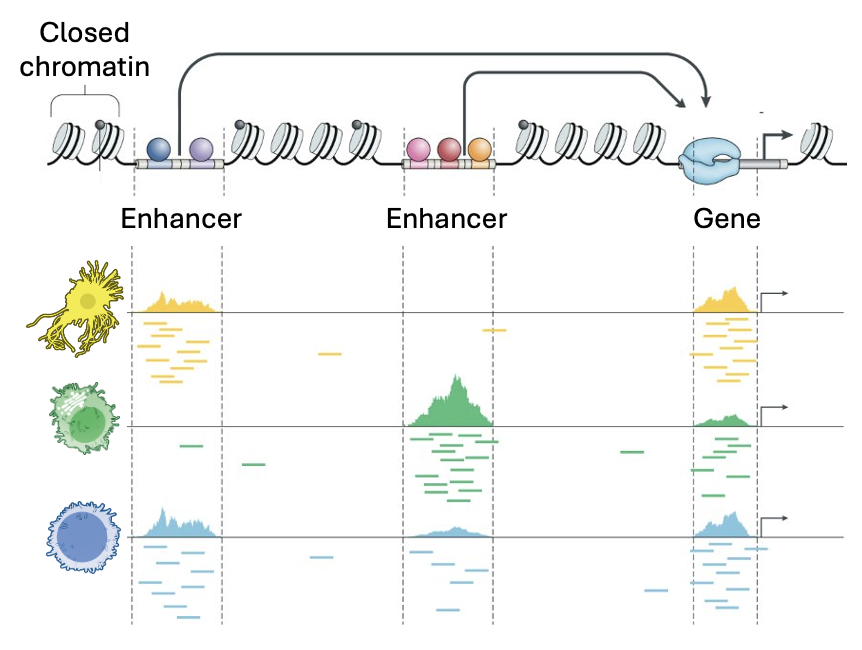
</div>

**Schematic.** A gene with two upstream enhancers, viewed in three cell types (top to bottom). In each cell type, only some enhancers are *accessible* — the ATAC tracks at right show what's measurable. The gene is expressed (right column) only in the cell type where its enhancer is open. The workshop's task is to recover this picture for a real gene from PBMC multiome data: pick a cell-type-specific gene, find its enhancer by paired peak-to-gene correlation, and ask which transcription factors bind it.

### What the data looks like

The `.h5mu` holds two matrices, one per modality, sharing the **same rows** (one row = one cell, matched by barcode):

| Modality | Rows (cells) | Columns | Values |
|---|---|---|---|
| RNA  | ~10,000 cells | ~19,000 genes | UMI counts |
| ATAC | ~10,000 cells | ~180,000 peaks (called with MACS3) | Tn5 cut counts |

The trick is the row alignment — **row *i* in RNA is the same physical cell as row *i* in ATAC**. Every downstream analysis leans on that.

In [4]:
# Concrete shapes + a few example features
print(f"RNA  matrix:  {rna.n_obs:>6,} cells x {rna.n_vars:>7,} genes")
print(f"ATAC matrix:  {atac.n_obs:>6,} cells x {atac.n_vars:>7,} peaks")
assert (rna.obs_names == atac.obs_names).all(), "barcodes mismatch!"
print(f"\nSame barcodes in both:  ✓  (e.g. {rna.obs_names[0]})")
print(f"\nExample genes : {list(rna.var_names[:6])}")
print(f"Example peaks : {list(atac.var_names[:3])}")

RNA  matrix:  10,138 cells x  18,842 genes
ATAC matrix:  10,138 cells x 179,458 peaks

Same barcodes in both:  ✓  (e.g. AAACAGCCAATCCCTT-1)

Example genes : ['LINC01409', 'FAM87B', 'LINC01128', 'LINC00115', 'FAM41C', 'SAMD11']
Example peaks : ['chr1:9924-10425', 'chr1:96340-96841', 'chr1:180650-181151']


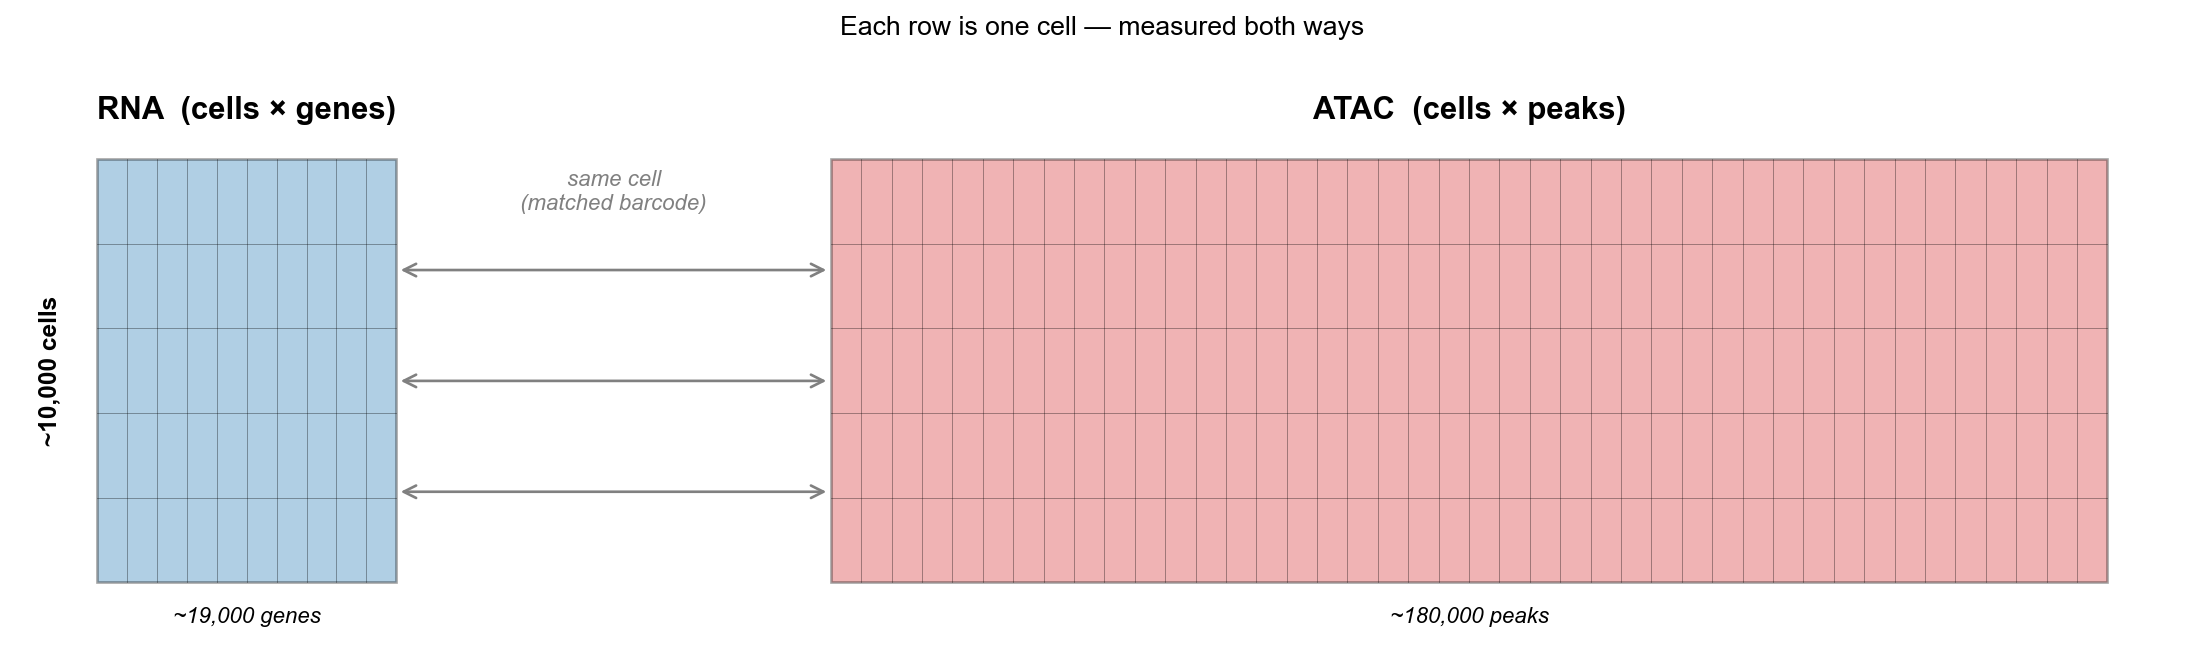

In [5]:
# Schematic: the two matrices, sharing rows.
# ATAC is drawn ~4x wider than RNA to convey that ATAC has ~10x more columns
# (~180k peaks vs ~19k genes) while sharing the same cell axis.
fig, ax = plt.subplots(figsize=(14, 4.4))
ax.set_xlim(0, 16); ax.set_ylim(0, 6); ax.axis('off')

def matrix(ax, x, w, label, cols_label, color, n_cols):
    ax.add_patch(plt.Rectangle((x, 0.7), w, 4.2, fc=color, ec='black', lw=1.2, alpha=0.35))
    # row lines (cells)
    for i in range(1, 5):
        ax.plot([x, x+w], [0.7+i*0.84, 0.7+i*0.84], color='black', lw=0.3, alpha=0.5)
    # column lines (features) — density set explicitly so RNA vs ATAC visually differ
    for j in range(1, n_cols):
        ax.plot([x+j*w/n_cols, x+j*w/n_cols], [0.7, 4.9], color='black', lw=0.3, alpha=0.5)
    ax.text(x+w/2, 5.3, label, ha='center', fontsize=14, fontweight='bold')
    ax.text(x+w/2, 0.3, cols_label, ha='center', fontsize=10, style='italic')

matrix(ax, 0.6, 2.2, 'RNA  (cells × genes)',  '~19,000 genes',  '#1f77b4', n_cols=10)
matrix(ax, 6.0, 9.4, 'ATAC  (cells × peaks)', '~180,000 peaks', '#d62728', n_cols=42)

# shared-cells axis label (left of RNA)
ax.text(0.25, 2.8, '~10,000 cells', ha='center', va='center', rotation=90,
        fontsize=11, fontweight='bold')
# arrows across the gap signaling same row
for y in [1.6, 2.7, 3.8]:
    ax.annotate('', xy=(6.0, y), xytext=(2.8, y),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
ax.text(4.4, 4.4, 'same cell\n(matched barcode)', ha='center', fontsize=10,
        color='gray', style='italic')
plt.title("Each row is one cell — measured both ways", fontsize=12)
plt.tight_layout(); plt.show()


## Part 2 — Two views of the same cells

Each modality knows about a cell only through its own features (genes for RNA, peaks for ATAC). Run dimensionality reduction + clustering on each independently and you get two embeddings — two UMAPs — built from completely different signals.

If both layers report the same biology, the clusters should look similar in shape. Do they?

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


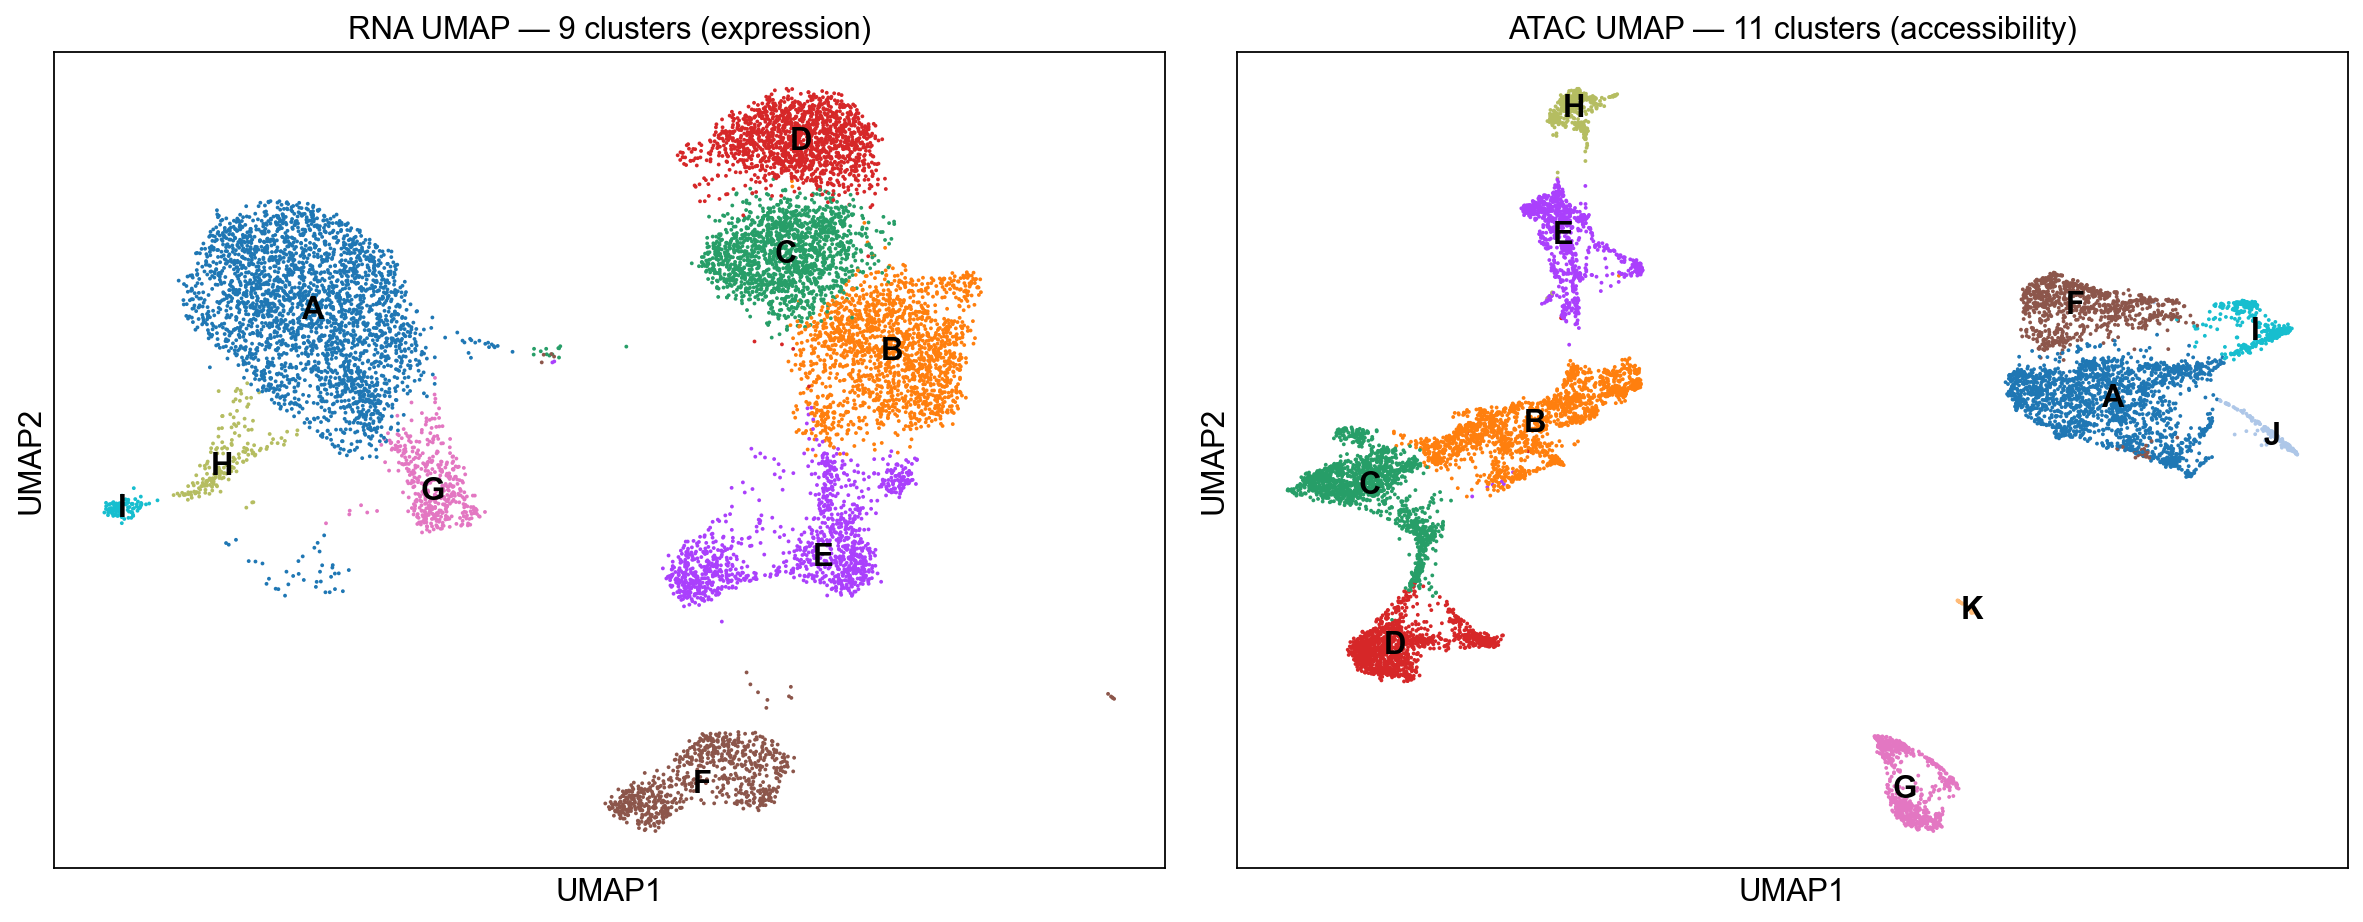

Two independent unsupervised partitionings of the same cells.
Similar number of groups, similar shape — but how do they correspond?


In [6]:
# Run unsupervised clustering on each modality *independently*, label clusters with letters,
# and show the two UMAPs side by side. No cell-type labels yet — just structure.
sc.pp.neighbors(rna, use_rep='X_pca', n_neighbors=15)
sc.tl.leiden(rna, resolution=0.3, key_added='cluster')
sc.pp.neighbors(atac, use_rep='X_spectral', n_neighbors=15)
sc.tl.leiden(atac, resolution=0.35, key_added='cluster')

# relabel numeric clusters to letters so neither side suggests biology
def to_letters(ad):
    cats = list(ad.obs['cluster'].cat.categories)
    mapping = {c: chr(ord('A')+i) for i, c in enumerate(cats)}
    ad.obs['cluster'] = ad.obs['cluster'].map(mapping).astype('category')
to_letters(rna); to_letters(atac)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(rna,  color='cluster', ax=axes[0], show=False, legend_loc='on data',
           title=f'RNA UMAP — {rna.obs.cluster.nunique()} clusters (expression)')
sc.pl.umap(atac, color='cluster', ax=axes[1], show=False, legend_loc='on data',
           title=f'ATAC UMAP — {atac.obs.cluster.nunique()} clusters (accessibility)')
plt.tight_layout(); plt.show()
print('Two independent unsupervised partitionings of the same cells.')
print('Similar number of groups, similar shape — but how do they correspond?')

### The integration question

Cluster **B** on the RNA UMAP and cluster **D** on the ATAC UMAP — are they the same cells? A different group? Partly overlapping?

For most multi-modal data this would be the hard problem: align the two embeddings (CCA, mutual nearest neighbors, GLUE, totalVI, …). For **paired multiome it's trivial** — every row of RNA shares a barcode with the same row of ATAC. We don't *align* the modalities; we already have the cell-to-cell mapping.

Concretely: take RNA's cluster labels and color them onto the ATAC UMAP. If the biology is shared, ATAC's geometry will respect them.

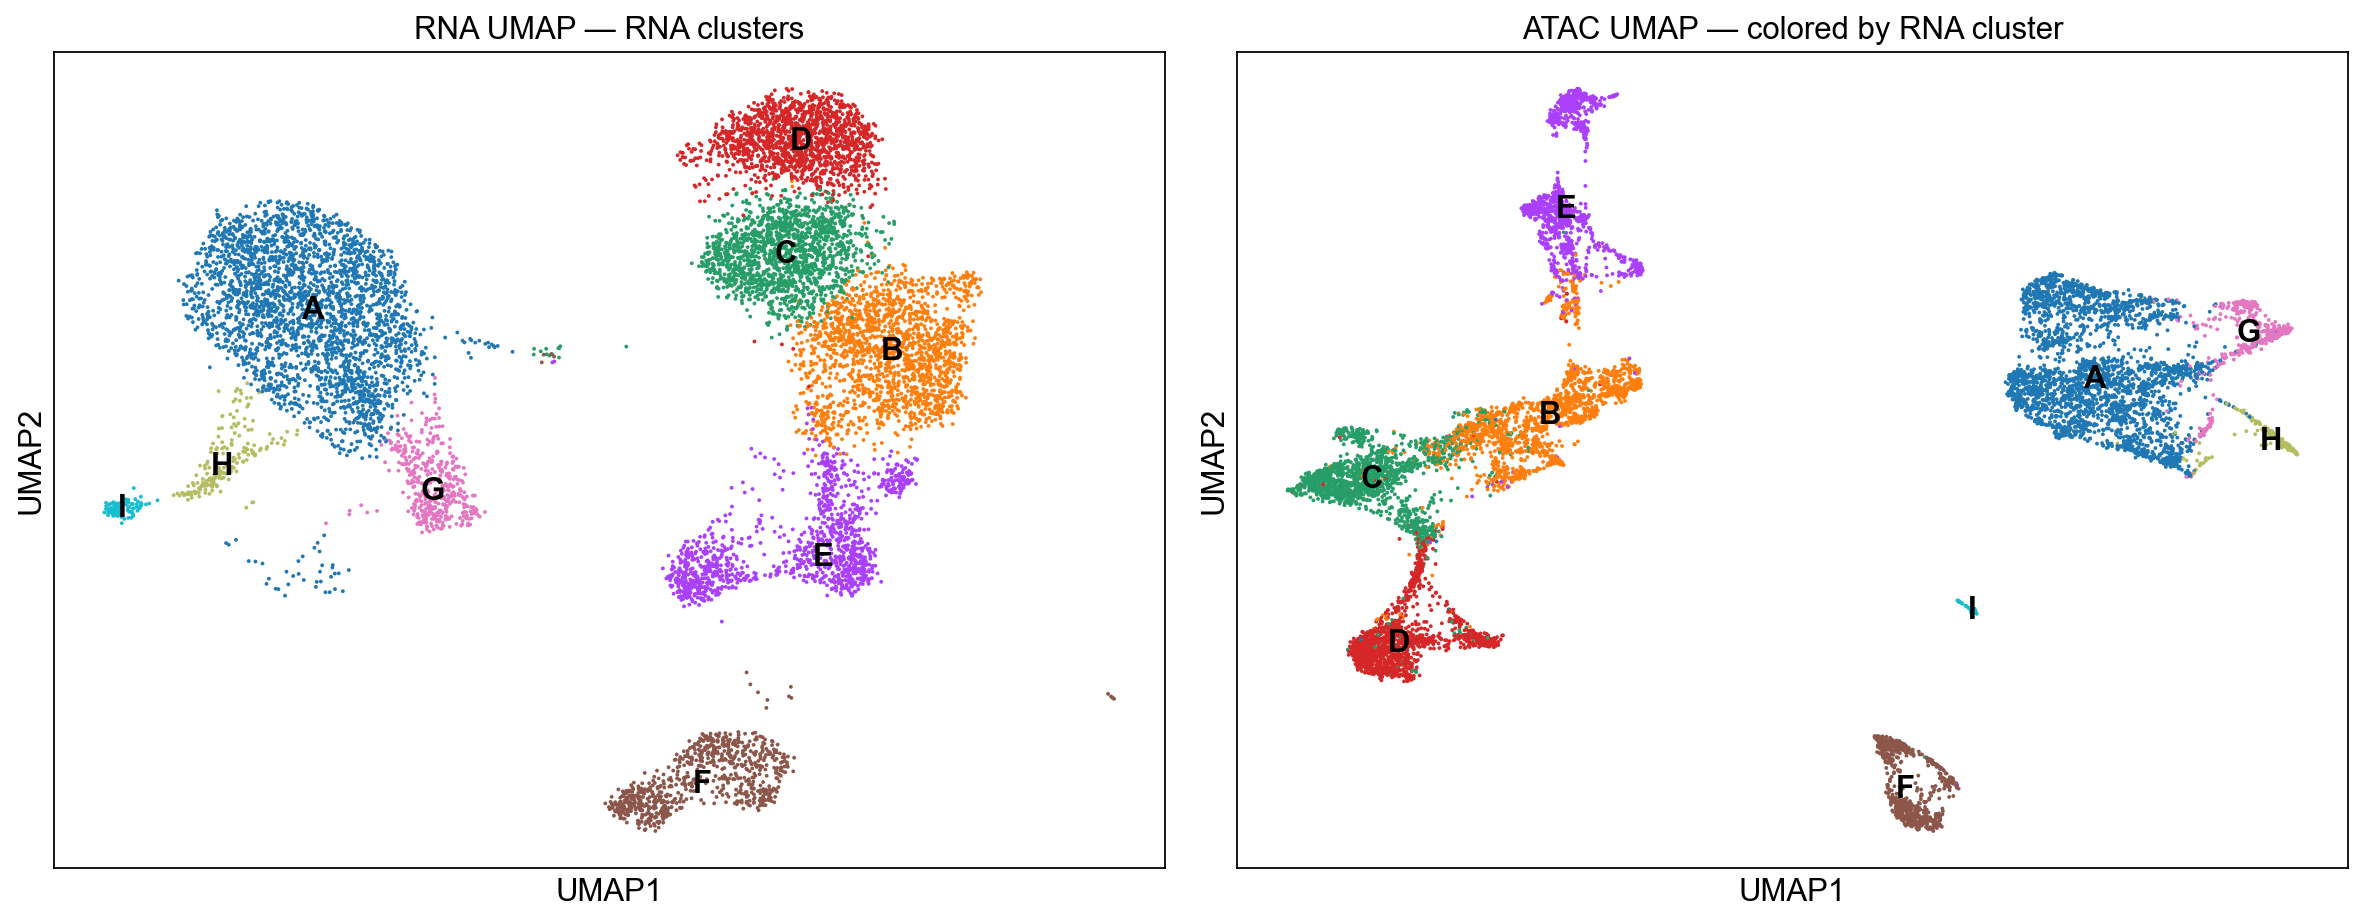

RNA-defined clusters land in coherent regions of the ATAC UMAP — the two layers
agree on what the cells *are*, without any explicit integration step.


In [7]:
# Carry RNA's clusters onto the ATAC embedding by shared barcode.
atac.obs['rna_cluster'] = rna.obs['cluster'].values
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(rna,  color='cluster',     ax=axes[0], show=False, legend_loc='on data',
           title='RNA UMAP — RNA clusters')
sc.pl.umap(atac, color='rna_cluster', ax=axes[1], show=False, legend_loc='on data',
           title='ATAC UMAP — colored by RNA cluster')
plt.tight_layout(); plt.show()
print('RNA-defined clusters land in coherent regions of the ATAC UMAP — the two layers')
print('agree on what the cells *are*, without any explicit integration step.')

### From clusters to cell types

The clusters are biology, but they don't come with names. To label them we score each cell against known PBMC marker-gene panels (CD79A/MS4A1 → B, CD3D/CD8A → CD8 T, …), pick the best match, and validate with DEGs. The full procedure is in `rna_annotation.ipynb`; here we consume the result (`obs['cell_type']`).

Once labeled, both UMAPs become biologically interpretable — same cells, same labels, two windows on the same identity.

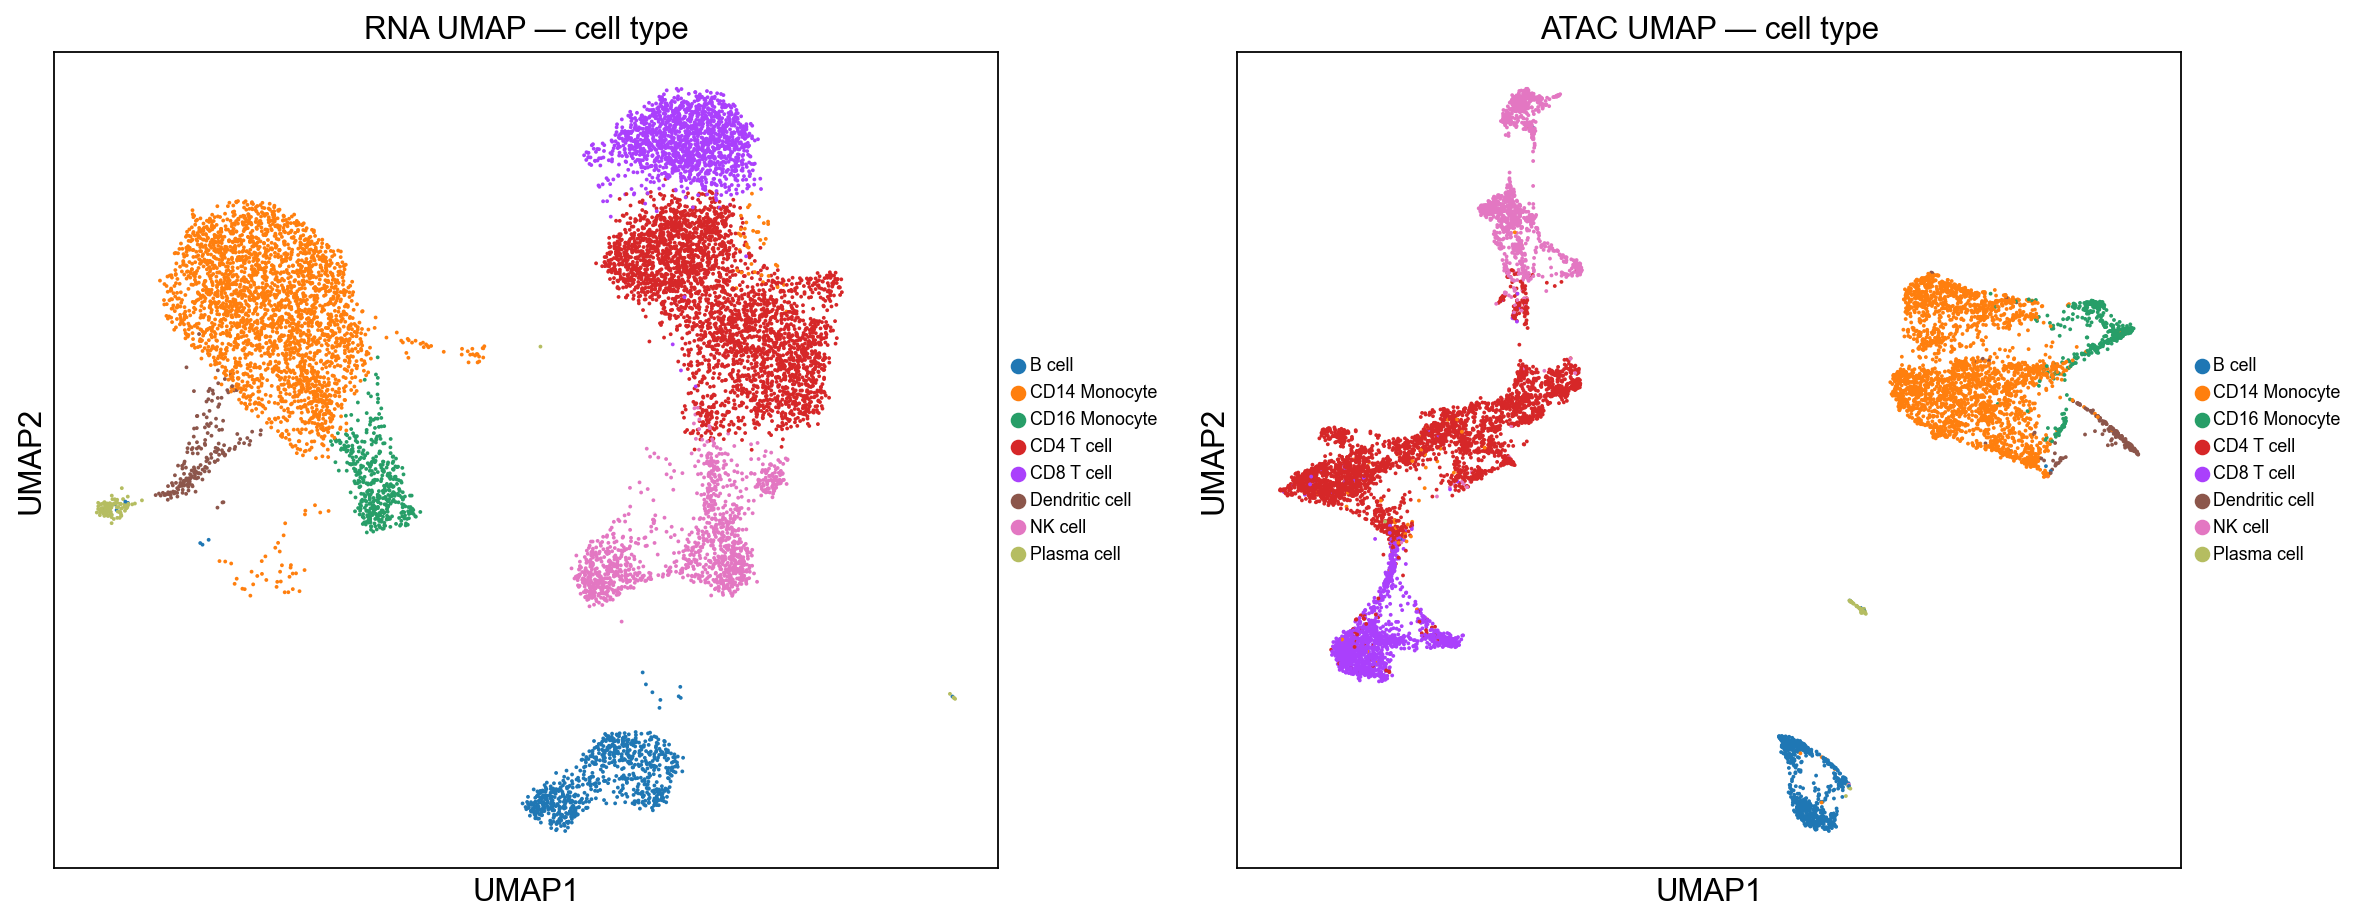

In [8]:
rna.obs['cell_type']  = rna.obs['cell_type'].astype('category')
atac.obs['cell_type'] = atac.obs['cell_type'].astype('category')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(rna,  color='cell_type', ax=axes[0], show=False, legend_loc='right margin',
           legend_fontsize=8, title='RNA UMAP — cell type')
sc.pl.umap(atac, color='cell_type', ax=axes[1], show=False, legend_loc='right margin',
           legend_fontsize=8, title='ATAC UMAP — cell type')
plt.tight_layout(); plt.show()

## Part 3 — Peak-to-gene linking

We can now ask the regulatory question. Take a gene that's clearly cell-type-specific — e.g. **MS4A1** (CD20), a B-cell marker. The gene is expressed only in B cells. Somewhere in the genome around MS4A1 there must be a regulatory element — an **enhancer** — that's *open* in B cells and *closed* elsewhere, driving that pattern.

The setup of paired multiome lets us search for it directly:

1. Take every ATAC peak within ±250 kb of MS4A1's TSS — the candidate window.
2. For each peak, compute the **Spearman correlation between its accessibility and MS4A1 expression across all cells**.
3. Rank peaks by correlation: the top hits are candidate regulatory elements.

This is exactly what `Signac::LinkPeaks`, `ArchR::addPeak2GeneLinks`, and Seurat compute — and it's the analysis paired multiome uniquely enables.

In [9]:
# === Feature setting — change here to re-target to a different gene ===
FEATURED_GENE = 'MS4A1'    # e.g. 'CD8A' (T-cell) or 'CD14' (monocyte)
# =======================================================================

# Normalize + log-transform the peak matrix for the analyses below.
# Idempotent: restore raw counts before re-applying, so re-running this cell
# (e.g. after changing FEATURED_GENE) doesn't double-log atac.X.
if "counts" not in atac.layers:
    atac.layers['counts'] = atac.X.copy()
else:
    atac.X = atac.layers['counts'].copy()
    atac.uns.pop('log1p', None)
sc.pp.normalize_total(atac, target_sum=1e4)
sc.pp.log1p(atac)


In [10]:
# Peak-to-gene by paired correlation; candidate window from the TSS (gene_tss in uns).
_tss = mdata.uns['gene_tss']
TSS = {g: (c, int(t)) for g, c, t in zip(_tss['gene'], _tss['chrom'], _tss['tss'])}
_pc = atac.var_names.str.extract(r'(?P<chrom>chr\w+)[:\-](?P<start>\d+)[:\-](?P<end>\d+)')
PEAKS = pd.DataFrame({'name': atac.var_names, 'chrom': _pc['chrom'].values,
                      'mid': ((_pc['start'].astype(int)+_pc['end'].astype(int))//2).values})

def dense(ad, name):
    col = ad[:, name].X
    return np.asarray(col.todense()).ravel() if sp.issparse(col) else np.asarray(col).ravel()

def link_to_gene(gene, window=250_000):
    chrom, tss = TSS[gene]
    near = PEAKS[(PEAKS.chrom==chrom) & (PEAKS.mid>=tss-window) & (PEAKS.mid<=tss+window)].copy()
    g = dense(rna, gene); rhos = []
    for nm in near['name']:
        a = dense(atac, nm)
        rhos.append(stats.spearmanr(a, g)[0] if a.std() > 0 else np.nan)
    near['rho']     = rhos
    near['dist_kb'] = ((near['mid'] - tss) / 1000).round(1)
    d = near['dist_kb'].abs()
    near['kind']    = np.where(d<2, 'promoter', np.where(d<10, 'gene-proximal', 'distal'))
    return near.sort_values('rho', ascending=False).reset_index(drop=True)

ranked = link_to_gene(FEATURED_GENE)
print(f"{FEATURED_GENE}: {len(ranked)} candidate peaks within ±250 kb of the TSS\n")
print(ranked[['name', 'rho', 'dist_kb', 'kind']].head(8).to_string(index=False))

_distal = ranked[ranked['kind'] == 'distal'].reset_index(drop=True)
FEATURED_PEAK = (_distal.iloc[0]['name'] if len(_distal) else ranked.iloc[0]['name'])
_fr = ranked[ranked['name'] == FEATURED_PEAK].iloc[0]
print(f"\nFeatured DISTAL enhancer: {FEATURED_PEAK} ({_fr['dist_kb']:+.1f} kb from TSS, rho={_fr['rho']:.2f})")

# cell-type groupings reused below
cts = rna.obs['cell_type'].astype(str).values
ct_order = list(rna.obs['cell_type'].cat.categories)
by_ct = {ct: np.where(cts == ct)[0] for ct in ct_order}

MS4A1: 69 candidate peaks within ±250 kb of the TSS

                   name      rho  dist_kb     kind
chr11:60455461-60455962 0.618976     -0.1 promoter
chr11:60498760-60499261 0.408484     43.2   distal
chr11:60477012-60477513 0.376334     21.4   distal
chr11:60457529-60458030 0.283311      1.9 promoter
chr11:60485868-60486369 0.261670     30.3   distal
chr11:60633638-60634139 0.213276    178.0   distal
chr11:60357730-60358231 0.204759    -97.9   distal
chr11:60684410-60684911 0.201572    228.8   distal

Featured DISTAL enhancer: chr11:60498760-60499261 (+43.2 kb from TSS, rho=0.41)


**Reading the table.** The highest ρ is usually the **promoter** (≈0 kb from the TSS) — expected, because a promoter opens whenever its gene is expressed. The interesting hit is the top **distal** peak: an element well away from the TSS whose accessibility tracks the gene's expression across cells — a candidate **enhancer**. That's what we'll zoom in on for the rest of Part 3.

### Three views of the featured enhancer

We have one candidate enhancer for MS4A1, picked by correlation across single cells. Three quick views, each answering one question:

- **Genome browser (IGV)** — *where* is it, relative to MS4A1? Is the accessibility cell-type-specific?
- **Pseudobulk scatter** — does per-cell-type accessibility actually track per-cell-type expression?
- **UMAP overlay** — is the enhancer accessible in the same cells that express the gene?

> *The IGV browser below is a live JavaScript widget — it appears blank on GitHub's static preview, but renders fully after **Runtime → Run all** in Colab.*

In [11]:
# Embedded IGV browser. Per-cell-type pseudobulk bigWigs streamed from GCS;
# window auto-fits the gene's TSS + the featured enhancer.
import igv_notebook, os
TRACKS = os.environ.get('TRACKS_URL',
    'https://storage.googleapis.com/broad-p16-calico/festival-2026/tracks')
chrom, se = FEATURED_PEAK.split(':'); ps, pe = map(int, se.split('-'))
_, gene_tss = TSS[FEATURED_GENE]
win_start = min(ps, gene_tss) - 20_000
win_end   = max(pe, gene_tss) + 20_000
LOCUS = f'{chrom}:{win_start:,}-{win_end:,}'

igv_notebook.init()
b = igv_notebook.Browser({'genome': 'hg38', 'locus': LOCUS})

# Highlight the candidate enhancer as a gold annotation track at the top.
b.load_track({
    'name':    f'{FEATURED_GENE} enhancer',
    'type':    'annotation',
    'format':  'bed',
    'color':   '#FFB400',        # gold
    'height':  22,
    'displayMode': 'EXPANDED',
    'features': [{'chr': chrom, 'start': ps - 200, 'end': pe + 200,
                  'name': f'{FEATURED_GENE} enhancer'}],
})

# Per-cell-type ATAC tracks.
for ct in ['B cell','CD4 T cell','CD8 T cell','NK cell','CD14 Monocyte','CD16 Monocyte','Dendritic cell']:
    safe = ct.replace(' ', '_')
    b.load_track({'name': ct, 'url': f'{TRACKS}/{safe}.bw', 'format': 'bigwig',
                  'type': 'wig', 'height': 32, 'color': '#1f77b4', 'autoscaleGroup': 'atac'})

print(f'Per-cell-type ATAC pseudobulk tracks; {FEATURED_GENE} is in the refseq track.')
print('The candidate enhancer is the gold annotation at the top of the browser.')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Per-cell-type ATAC pseudobulk tracks; MS4A1 is in the refseq track.
The candidate enhancer is the gold annotation at the top of the browser.


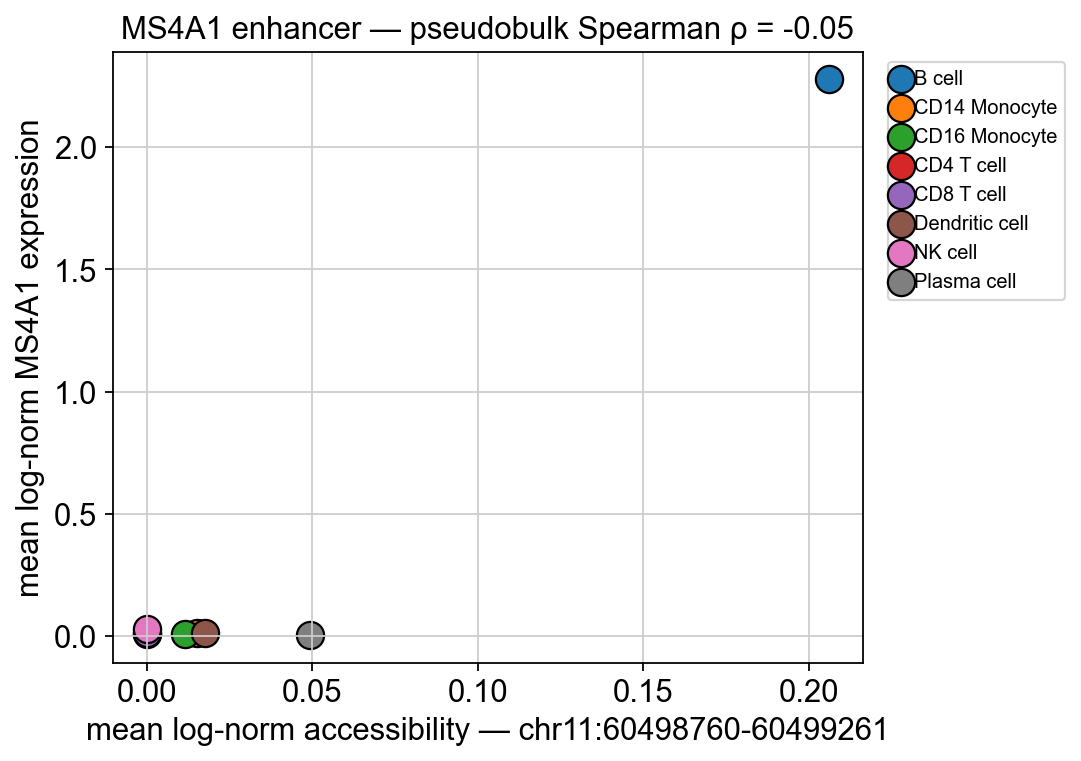

Enhancer accessibility and MS4A1 expression peak in the same cell type.


In [12]:
# Pseudobulk: one point per cell type — enhancer accessibility vs gene expression.
gene_expr = dense(rna, FEATURED_GENE); peak_acc = dense(atac, FEATURED_PEAK)
x = np.array([peak_acc[by_ct[c]].mean() for c in ct_order])
y = np.array([gene_expr[by_ct[c]].mean() for c in ct_order])
rho_pb, _ = stats.spearmanr(x, y)
fig, ax = plt.subplots(figsize=(7, 5)); colors = plt.get_cmap('tab10').colors
for i, c in enumerate(ct_order):
    ax.scatter(x[i], y[i], s=150, color=colors[i%10], label=c, edgecolor='black')
ax.set_xlabel(f'mean log-norm accessibility — {FEATURED_PEAK}')
ax.set_ylabel(f'mean log-norm {FEATURED_GENE} expression')
ax.set_title(f'{FEATURED_GENE} enhancer — pseudobulk Spearman ρ = {rho_pb:.2f}')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()
print(f'Enhancer accessibility and {FEATURED_GENE} expression peak in the same cell type.')

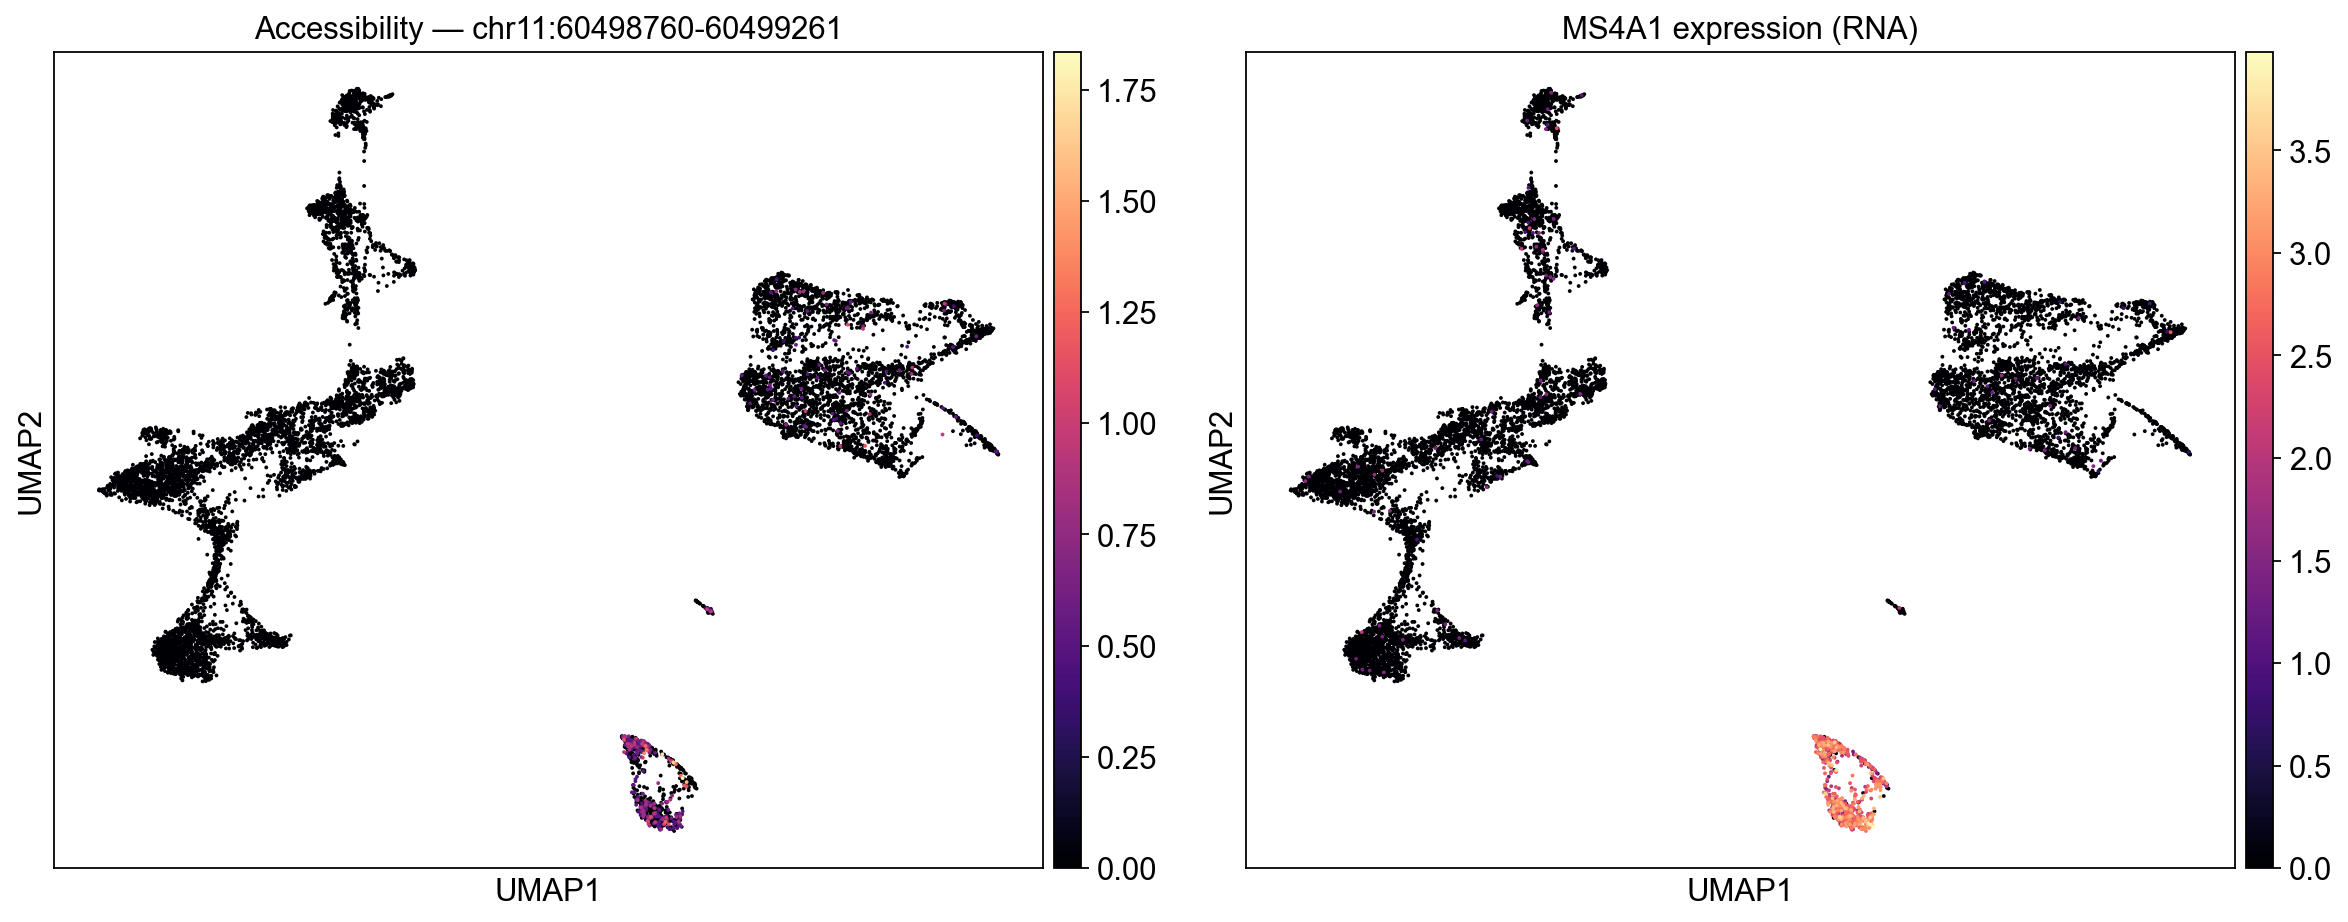

In [13]:
# Overlay on the ATAC UMAP: where is the enhancer accessible, vs where is the gene expressed?
atac.obs['featured_peak_acc'] = dense(atac, FEATURED_PEAK)
expr_col = f'{FEATURED_GENE}_expr'
atac.obs[expr_col] = dense(rna, FEATURED_GENE)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(atac, color='featured_peak_acc', ax=axes[0], show=False,
           title=f'Accessibility — {FEATURED_PEAK}', cmap='magma')
sc.pl.umap(atac, color=expr_col, ax=axes[1], show=False,
           title=f'{FEATURED_GENE} expression (RNA)', cmap='magma')
plt.tight_layout(); plt.show()

## Part 4 — Closing the loop: which transcription factors bind?

We have a candidate enhancer. But correlation tells us *where* the regulation happens, not *who* is doing it. Some transcription factor binds that DNA in B cells and turns the gene on; another doesn't bind it in T cells, and the chromatin stays closed.

There are three ways to identify that TF:

1. **ChIP-seq** — directly measure which TF is bound where. Gold standard, but you need a separate ChIP-seq experiment per TF per cell type. None of that data is in our multiome.
2. **Motif scanning** — search the enhancer for known TF binding motifs. Cheap, but noisy: motifs are short and degenerate, so dozens of candidate TFs match almost any element.
3. **Sequence models** — train a deep network to predict, from sequence alone, what would happen at any locus in any cell type (TF binding, accessibility, expression). Then ask the model.

We use the third. **AlphaGenome** is the model.

### What AlphaGenome predicts

[AlphaGenome](https://www.alphagenomedocs.com) is a deep-learning model trained on thousands of functional-genomics tracks from the [ENCODE project](https://www.encodeproject.org/) — ChIP-seq, DNase, ATAC, RNA, histone marks, methylation, splicing — across many cell types. It takes **~1 Mb of DNA sequence** as input and emits **predicted profiles** for any track in its panel.

The track we'll use is the **CHIP-TF head**: for a given transcription factor in a given biosample, the model predicts a binding signal at every position across the input window. We can ask: *"For this 1 Mb region centered on the MS4A1 enhancer, predict TF binding profiles for the B-cell-relevant TFs in the panel."*

A few important things:

- The model never sees our cells. Predictions come from **sequence alone**, conditioned on a target biosample (primary immune cell ontologies, plus GM12878 as a B-cell-line fallback).
- The cache in this `.h5mu` was built by querying AlphaGenome once for the MS4A1 enhancer's 1 Mb context, then saving the returned tracks. Students don't need an API key to run Part 4 as-is.
- With an [AlphaGenome API key](https://deepmind.google.com/science/alphagenome) (free for academic / non-commercial use, ~1 min to request), the same code path queries live for *any* enhancer — so re-targeting Part 3 also re-targets Part 4. In Colab, add it via the 🔑 sidebar as `ALPHA_GENOME_API_KEY`.


In [14]:
# Either query AlphaGenome live (with API key) or read the baked cache.
# Both paths dedup to ONE row per TF: the (TF, biosample) with the strongest
# predicted signal inside the enhancer +/-2 kb -- so they're directly comparable.
import os, re
try:
    from google.colab import userdata
    API_KEY = userdata.get("ALPHA_GENOME_API_KEY")
except Exception:
    API_KEY = os.environ.get("ALPHA_GENOME_API_KEY")

def dedup_by_tf(pos, vals, tfs, bios, ps, pe):
    """Keep one row per TF -- the biosample with the highest max-signal in +/-500 bp."""
    window = (pos >= ps -  500) & (pos <= pe +  500)
    sig = vals[window].max(axis=0)
    best = {}
    for i, tf in enumerate(tfs):
        if tf not in best or sig[i] > best[tf][1]:
            best[tf] = (i, sig[i])
    items = sorted(best.items(), key=lambda kv: -kv[1][1])
    idx = [v[1][0] for v in items]
    return pos, vals[:, idx], tfs[idx], bios[idx], ps, pe

def predict_dropping_unsupported(model, ctx, dna_client, terms):
    """Call predict_interval, but if AlphaGenome rejects an ontology term, drop it and retry.
    Useful because not every Cell Ontology / EFO term is in AlphaGenome's vocabulary."""
    terms = list(terms)
    while True:
        try:
            return model.predict_interval(interval=ctx,
                requested_outputs=[dna_client.OutputType.CHIP_TF],
                ontology_terms=terms), terms
        except Exception as e:
            m = re.search(r'Unsupported ontology: "([^"]+)"', str(e))
            if not m or not terms:
                raise
            bad = m.group(1)
            print(f"  AlphaGenome does not support {bad}; dropping and retrying.")
            terms = [t for t in terms if t != bad]

def load_ag_live(peak):
    from alphagenome.data import genome
    from alphagenome.models import dna_client
    TF_PANEL = ["EBF1","PAX5","SPIB","TCF3","POU2F2","SPI1","CEBPA","CEBPB","IRF8",
                "RUNX3","ETS1","TBX21","EOMES","TCF7","LEF1","GATA3","BCL11A","CTCF"]
    # Primary PBMC immune ontologies (preferred over cell lines for PBMC interp),
    # plus GM12878 as a B-lymphoblastoid fallback where primary-B ChIP-TF is sparse.
    # If AlphaGenome rejects an ontology term, predict_dropping_unsupported
    # drops it and retries -- supported terms can change over time.
    BIOSAMPLES = [
        # Primary PBMC immune ontologies (best for interpretation when data exists).
        "CL:0000236",   # B cell
        "CL:0000623",   # natural killer cell
        "CL:0000624",   # CD4+ alpha-beta T cell
        "CL:0000625",   # CD8+ alpha-beta T cell
        "CL:0000576",   # monocyte
        "CL:0001054",   # CD14+ monocyte
        # Cell lines — most ENCODE CHIP-TF data lives here. Each one's role:
        "EFO:0002784",  # GM12878 — B-lymphoblastoid (EBF1/PAX5/POU2F2/SPI1 etc.)
        "EFO:0002067",  # K562    — myeloid leukemia (CEBPA/GATA1/RUNX1/SPI1 myeloid)
        "EFO:0002796",  # Jurkat  — T-cell leukemia (T-cell TF ChIP-seq)
    ]
    chrom, se = peak.split(":"); s, e = map(int, se.split("-"))
    ctx = genome.Interval(chrom, s, e).resize(dna_client.SEQUENCE_LENGTH_1MB)
    model = dna_client.create(API_KEY)
    out, used_biosamples = predict_dropping_unsupported(model, ctx, dna_client, BIOSAMPLES)
    print(f"  biosamples used: {used_biosamples}")
    vals = out.chip_tf.values
    tfs  = out.chip_tf.metadata["transcription_factor"].astype(str).values
    bios = out.chip_tf.metadata["biosample_name"].astype(str).values
    keep = np.isin(tfs, TF_PANEL)
    pos = np.linspace(ctx.start, ctx.end, vals.shape[0])
    return dedup_by_tf(pos, vals[:, keep], tfs[keep], bios[keep], s, e)

def load_ag_cache():
    c = mdata.uns["alphagenome_cache"]
    vals = np.asarray(c["chip_tf_values"])
    md_  = pd.DataFrame({k: np.asarray(v) for k, v in c["chip_tf_metadata"].items()})
    pos  = np.linspace(int(c["context_start"]), int(c["context_end"]), vals.shape[0])
    pos, vals, tfs, bios, ps, pe = dedup_by_tf(
        pos, vals,
        md_["transcription_factor"].astype(str).values,
        md_["biosample_name"].astype(str).values,
        int(c["peak_start"]), int(c["peak_end"]),
    )
    return pos, vals, tfs, bios, ps, pe, c["featured_peak"]

if API_KEY:
    pos, vals, tfs, bios, ps, pe = load_ag_live(FEATURED_PEAK)
    source = f"live AlphaGenome query for {FEATURED_PEAK}"
else:
    pos, vals, tfs, bios, ps, pe, cached_peak = load_ag_cache()
    source = f"baked cache (featured peak: {cached_peak})"
    if cached_peak != FEATURED_PEAK:
        print(f"WARNING: Cache is for {cached_peak}, not {FEATURED_PEAK}. Set ALPHA_GENOME_API_KEY to query live.")

print(f"Source: {source}")
print(f"Context window: {len(pos):,} positions across ~{(pos[-1]-pos[0])/1e6:.2f} Mb")
print(f"Peak region:    {ps:,}-{pe:,}  ({pe-ps:,} bp)")
print(f"\nTFs returned ({vals.shape[1]}, one row per TF -- strongest biosample):")
print(pd.DataFrame({'TF': tfs, 'biosample': bios}).to_string(index=False))


Source: baked cache (featured peak: chr11:60498760-60499261)
Context window: 8,192 positions across ~1.05 Mb
Peak region:    60,498,760-60,499,261  (501 bp)

TFs returned (13, one row per TF -- strongest biosample):
    TF biosample
  SPI1   GM12878
  EBF1   GM12878
  TCF3   GM12878
  PAX5   GM12878
 TBX21   GM12878
BCL11A   GM12878
POU2F2   GM12878
 RUNX3   GM12878
  ETS1   GM12878
  CTCF    B cell
  TCF7   GM12878
  LEF1      K562
 CEBPB      K562


### Ranking TFs at the enhancer

For each TF, take the **maximum predicted binding signal within the enhancer (±2 kb)**. Higher = the model thinks this TF binds the enhancer more strongly. Rank them — the top hits are the model's best guesses for what regulates this element.

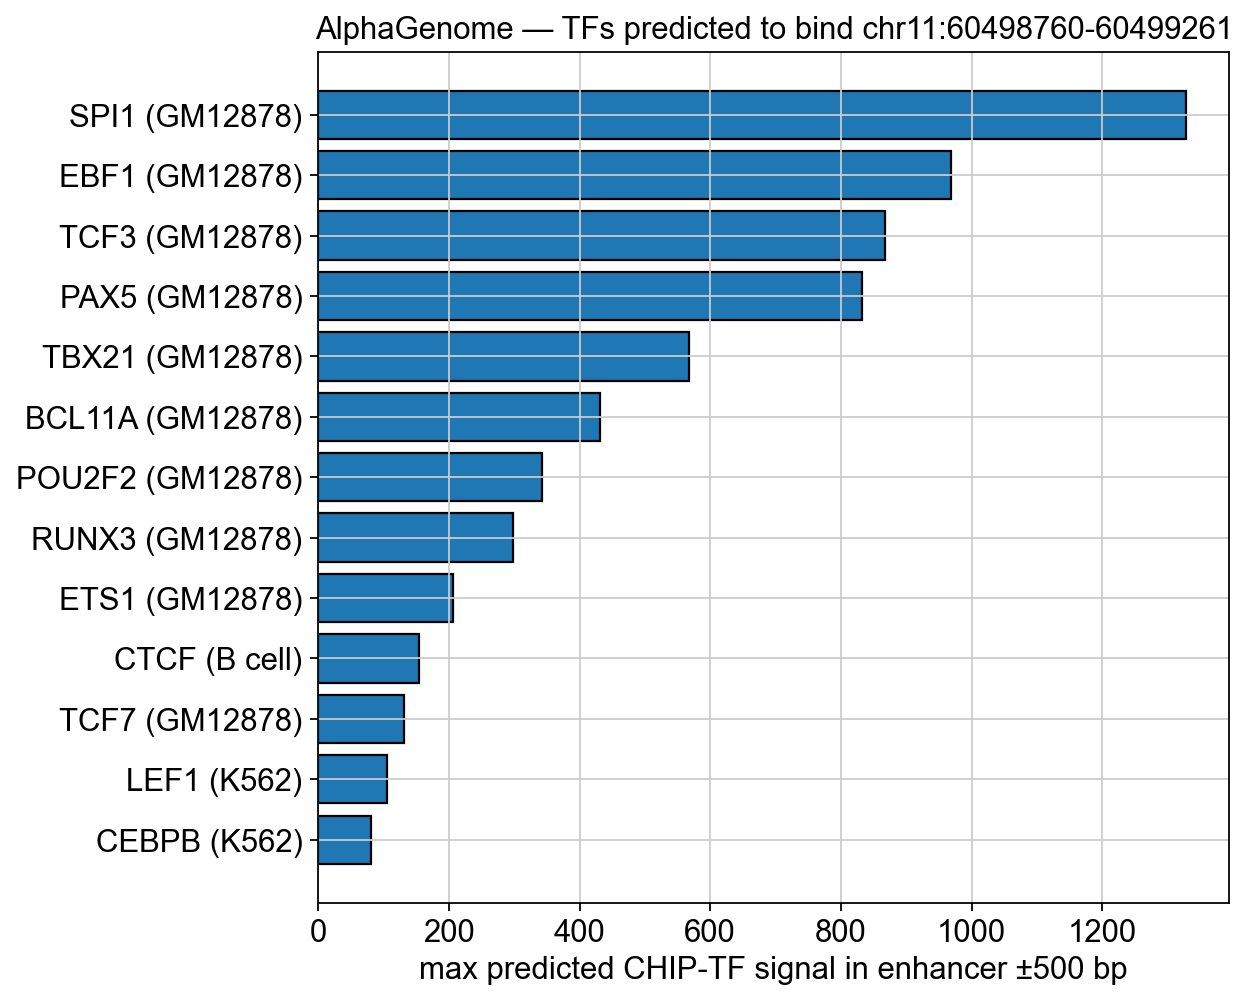

Ranked scores:
  SPI1     (GM12878 )  1328.0
  EBF1     (GM12878 )   968.0
  TCF3     (GM12878 )   868.0
  PAX5     (GM12878 )   832.0
  TBX21    (GM12878 )   568.0
  BCL11A   (GM12878 )   432.0
  POU2F2   (GM12878 )   342.0
  RUNX3    (GM12878 )   298.0
  ETS1     (GM12878 )   206.0
  CTCF     (B cell  )   154.0
  TCF7     (GM12878 )   131.0
  LEF1     (K562    )   105.5
  CEBPB    (K562    )    81.5


In [15]:
# Score each TF by its max predicted signal within the enhancer (±500 bp buffer).
window = (pos >= ps-500)  & (pos <= pe+500)
scores = vals[window].max(axis=0)
order  = np.argsort(-scores)

# Compact label (TF + biosample so duplicates are distinguishable)
labels = [f"{tfs[i]} ({bios[i]})" for i in order]

fig, ax = plt.subplots(figsize=(8, max(2.5, 0.5*len(order))))
ax.barh(range(len(order)), scores[order], color='#1f77b4', edgecolor='black')
ax.set_yticks(range(len(order))); ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('max predicted CHIP-TF signal in enhancer ±500 bp')
ax.set_title(f'AlphaGenome — TFs predicted to bind {FEATURED_PEAK}')
plt.tight_layout(); plt.show()

print('Ranked scores:')
for i in order:
    print(f"  {tfs[i]:<8} ({bios[i]:<8})  {scores[i]:6.1f}")

### Where on the locus does each TF bind?

The bar plot summarizes *how strongly* each TF binds. The full prediction is a profile — a signal value at every position across the 1 Mb context — so we can also see *where* the model places each binding event. We expect the top TFs' predictions to peak right at the open enhancer.

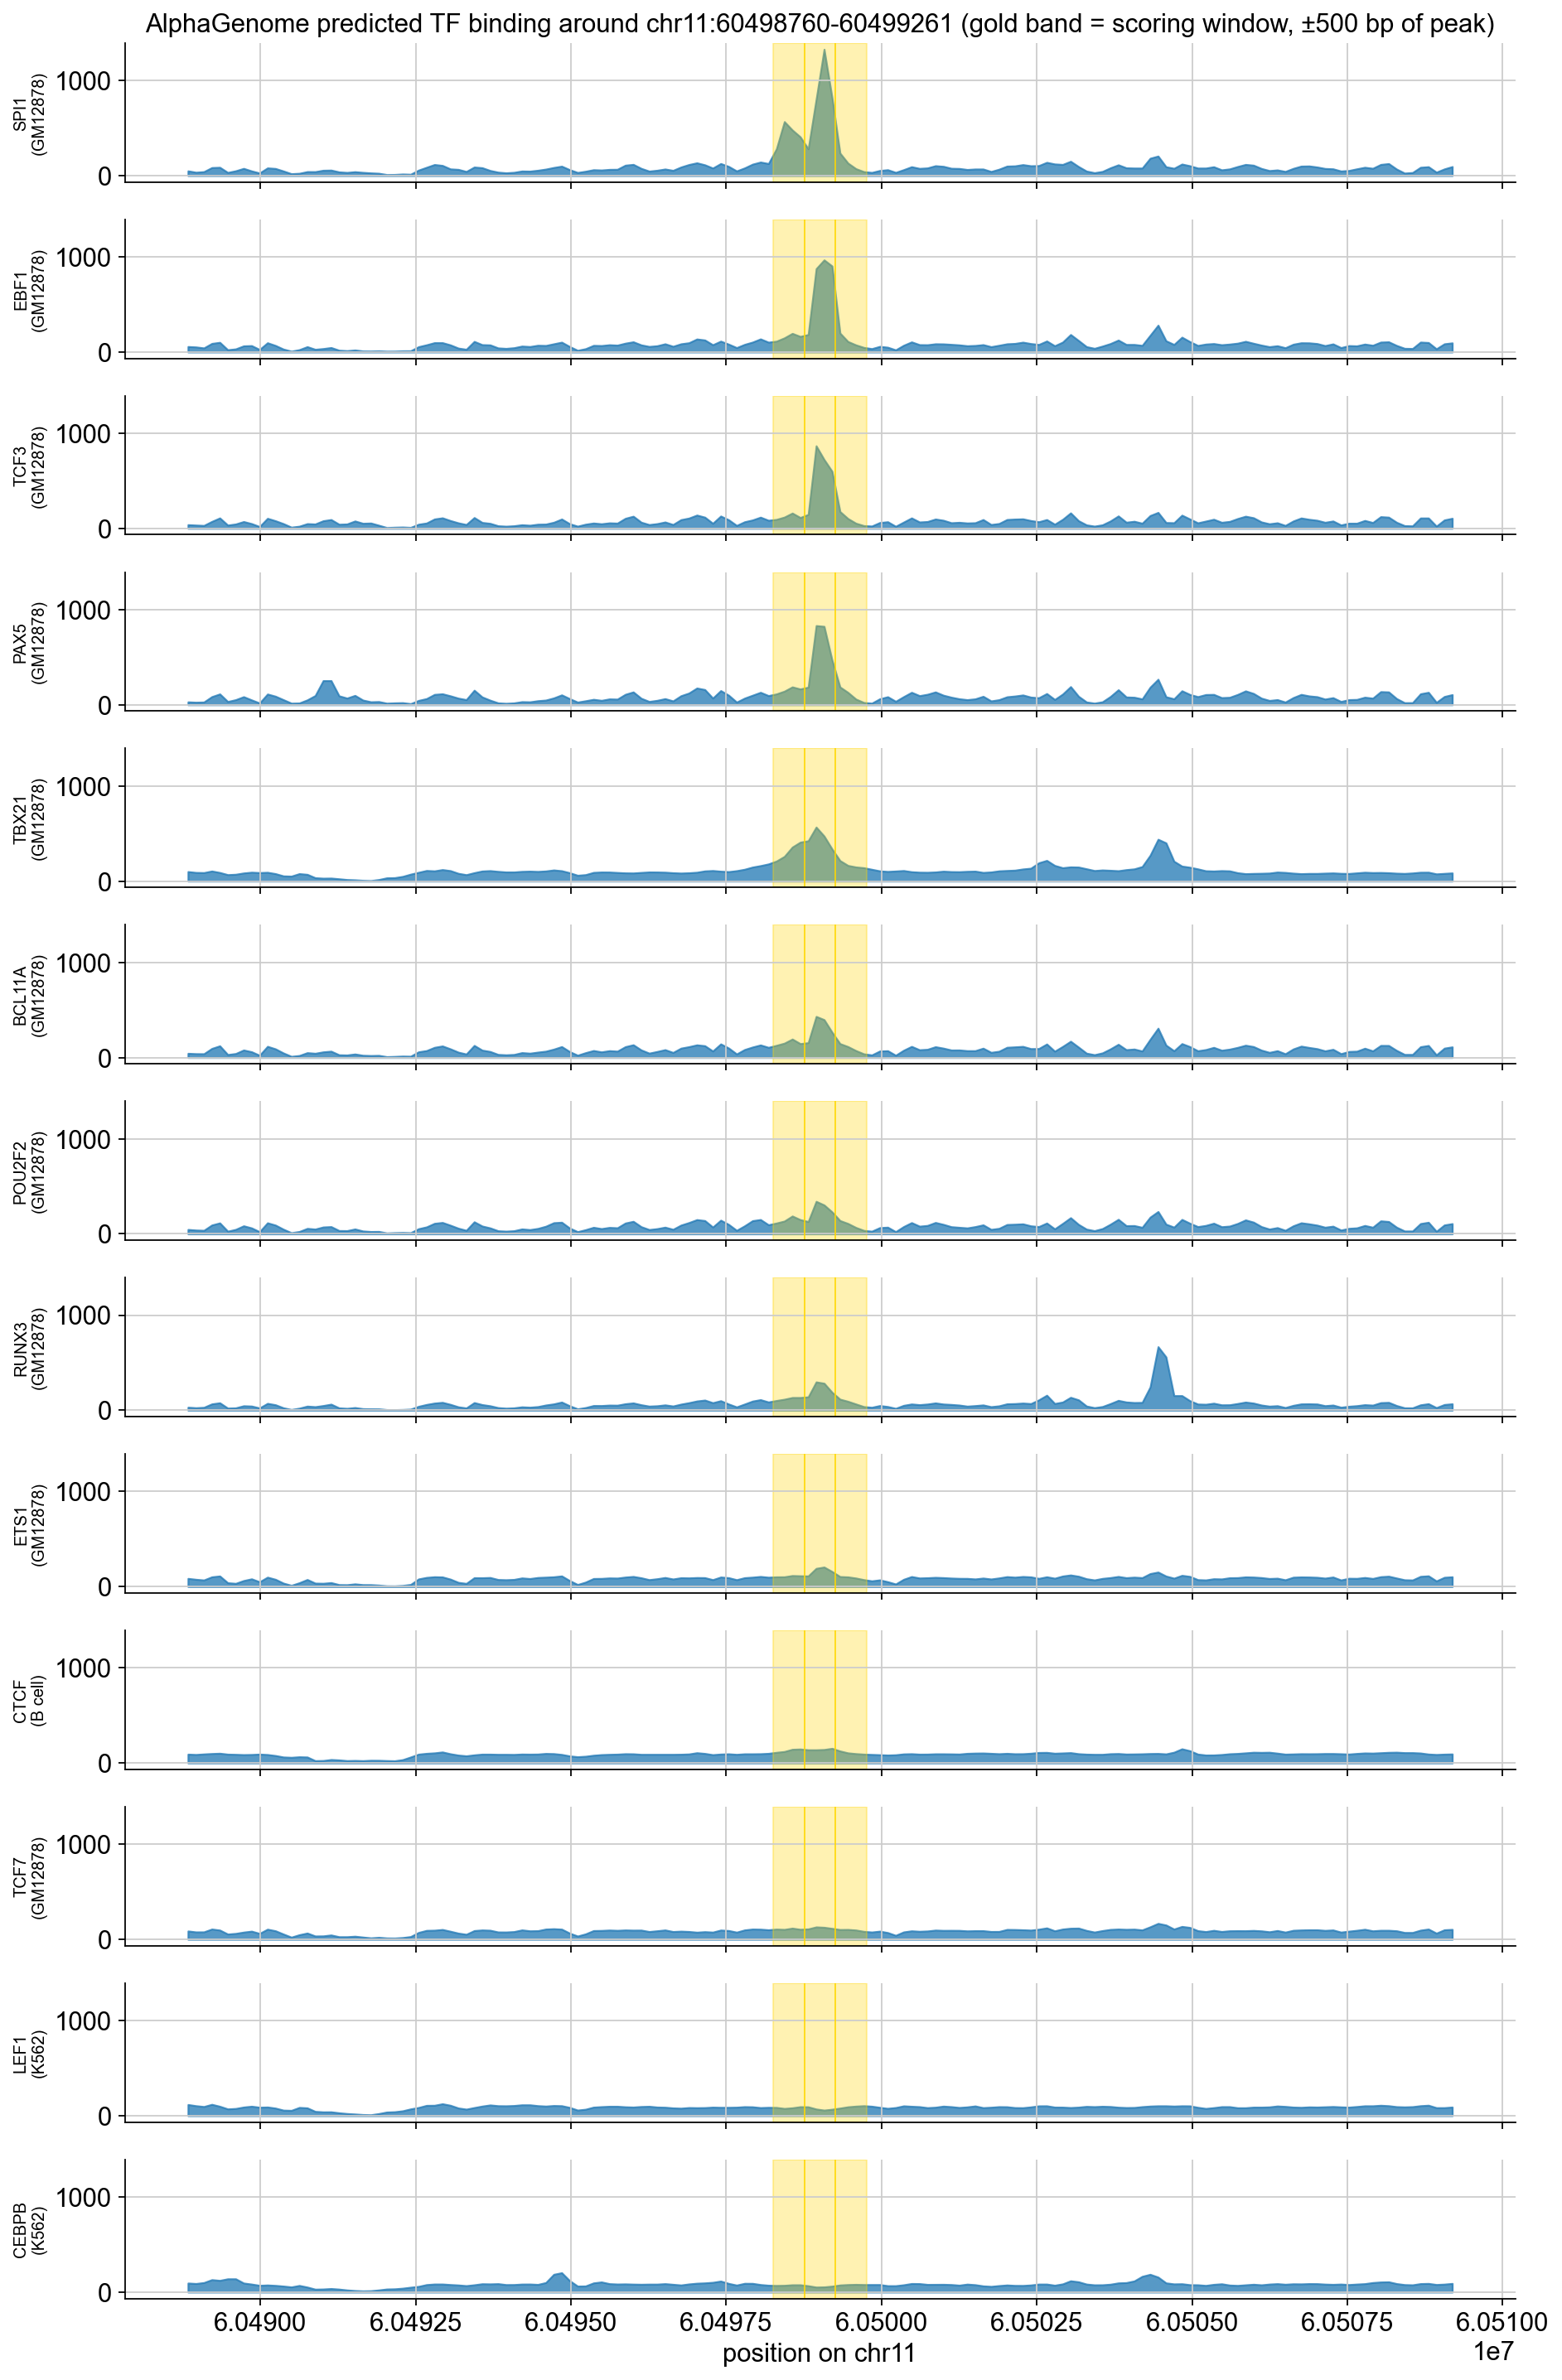

Visual height inside the gold band corresponds to each TF's ranked score above.
A taller peak outside the gold band does NOT contribute to the score.


In [16]:
# Predicted binding profile for each TF, zoomed to ±10 kb around the enhancer.
# Gold band is the scoring window (peak ±500 bp) — the same range used for the
# bar plot above, so the visual height matches the ranked scores.
zoom = (pos >= ps-10_000) & (pos <= pe+10_000)
fig, axes = plt.subplots(len(order), 1, figsize=(12, max(2.5, 1.4*len(order))),
                         sharex=True, sharey=True, squeeze=False)
axes = axes.ravel()
for ax, i in zip(axes, order):
    ax.fill_between(pos[zoom], vals[zoom, i], color='#1f77b4', alpha=0.75)
    ax.axvspan(ps-500,  pe+500,  color='gold', alpha=0.30)   # scoring window
    ax.axvline(ps, color='gold', lw=0.8, alpha=0.9)          # peak edges
    ax.axvline(pe, color='gold', lw=0.8, alpha=0.9)
    ax.set_ylabel(f"{tfs[i]}\n({bios[i]})", fontsize=9)
    ax.spines[['top','right']].set_visible(False)
axes[0].set_title(f'AlphaGenome predicted TF binding around {FEATURED_PEAK} '
                  '(gold band = scoring window, ±500 bp of peak)')
axes[-1].set_xlabel(f'position on {FEATURED_PEAK.split(":")[0]}')
plt.tight_layout(); plt.show()
print("Visual height inside the gold band corresponds to each TF's ranked score above.")
print("A taller peak outside the gold band does NOT contribute to the score.")


### Do these TFs make biological sense?

The TFs the model returns are not a random sample. They are the **hematopoietic / B-lineage transcription factor program**:

| TF | Role |
|---|---|
| **SPI1** (PU.1) | Pioneer hematopoietic TF; opens lineage enhancers in B and myeloid cells. Often the strongest predicted binder at B-cell enhancers because PU.1 helps prime the chromatin. |
| **EBF1** | *Early B-cell Factor 1.* Master B-lineage specifier — without it cells can't commit to B identity. |
| **PAX5** | Locks committed cells into the B program and represses non-B fates. Lose PAX5, you lose B identity even after commitment. |
| **TCF3** (E2A) | Required for early B-lineage specification, partners with EBF1. |
| **POU2F2** (OCT2) | B-cell-restricted TF; directly activates immunoglobulin genes. |

The model wasn't told "predict B-cell TFs." It was told to predict CHIP-TF binding from sequence for a panel of TFs across primary PBMC immune-cell biosamples plus three ENCODE cell lines (GM12878 / B-lymphoblastoid, K562 / myeloid, Jurkat / T-cell) where the bulk of CHIP-TF training data lives. It returned the B-master regulators — predicted to bind the very element our paired-correlation analysis flagged as MS4A1's distal enhancer.


### The closed regulatory loop

Reading the workshop end-to-end:

1. **Two views, one cell.** RNA and ATAC measure different molecules; clustering each independently recovers the same cell groups, and shared barcodes let us connect them without any explicit integration model.
2. **Cells become cell types** through marker-based annotation (RNA), carried to ATAC for free.
3. **MS4A1's enhancer**, ~43 kb from its TSS, falls out of paired peak-to-gene correlation — accessibility tracks expression across cells.
4. **That enhancer is B-cell-specific** in the IGV view, the pseudobulk scatter, and the UMAP overlay.
5. **The TFs predicted to bind it** are the master B-lineage regulators (EBF1, PAX5, TCF3, POU2F2, SPI1) — predicted from sequence alone, with no use of our experiment's ATAC or RNA in the prediction step.

End-to-end mechanism, from raw counts to TF binding, built from one dataset and one sequence model.

**Caveat.** AlphaGenome's CHIP-TF tracks come from cell lines (GM12878, K562); the model predicts binding *compatibility* from sequence, not in vivo occupancy in our PBMCs. The match between the predicted regulators and the biology of the cells where the enhancer is open is the validation.

## Summary

| Step | Method | Output |
|---|---|---|
| Two UMAPs | independent PCA + Leiden on RNA, spectral + Leiden on ATAC | concordant cluster structure |
| Cross-modal labels | shared barcode → carry RNA clusters/types onto ATAC | identity in both layers, no integration model |
| Peak-to-gene | per-gene Spearman correlation across single cells in ±250 kb window | candidate enhancers ranked by ρ |
| Browser + scatter + UMAP | per-cell-type pseudobulk bigWigs (IGV), pseudobulk scatter, UMAP overlay | the enhancer is B-cell-specific |
| TF binding | AlphaGenome CHIP-TF prediction from sequence | EBF1, PAX5, TCF3, POU2F2, SPI1 predicted to bind |

### Try it yourself

- Change `FEATURED_GENE` (CD8A, LEF1, IRF8, …) and Run All — peak-to-gene, IGV, scatter, UMAP, and (with an API key) AlphaGenome all follow.
- Change `TF_PANEL` in the AlphaGenome cell to include myeloid (CEBPA/CEBPB) or T-cell (TBX21, EOMES) TFs — re-target to a different gene and see if the right lineage TFs come back.
- Inspect the cache directly: `mdata.uns['alphagenome_cache']`.

### Source code

All preprocessing scripts and the notebook source live in the workshop's [GitHub repository](https://github.com/nchernia/festival-multiomics-workshop):

- `preprocess_pbmc_multiome.py` — full pipeline (download → QC → MACS3 → annotate → save)
- `cleanup_h5mu.py` — one-shot fixer (plasma-cell split + GLUE-residue strip)
- `refresh_alphagenome.py` — populate the AlphaGenome CHIP-TF cache (needs API key)
- `make_pseudobulk_bigwigs.py` — per-cell-type bigWigs for the IGV view
- `rna_annotation.ipynb` — companion notebook on how cell types were derived

### Resources

- scanpy: <https://scanpy.readthedocs.io>
- snapatac2: <https://kzhang.org/SnapATAC2/>
- igv-notebook: <https://github.com/igvteam/igv-notebook>
- AlphaGenome: <https://www.alphagenomedocs.com>
- 10x Multiome: <https://www.10xgenomics.com/datasets>